# 01 — Corpus Inspection

Inspect the raw pages and chunks produced by `hf-fetch` and `hf-chunk`.
Run the pipeline first:

```bash
uv run hf-fetch
uv run hf-chunk
```

In [14]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

DATA = Path("../data")

## Raw pages

In [15]:
with open(DATA / "raw_pages.json", encoding="utf-8") as f:
    pages = json.load(f)

print(f"{len(pages)} pages fetched\n")
print(f"{'Path':<52} {'Words':>6}  Title")
print("-" * 80)
for p in sorted(pages, key=lambda x: x["path"]):
    words = len(p["content"].split())
    print(f"{p['path']:<52} {words:>6}  {p['title']}")

16 pages fetched

Path                                                  Words  Title
--------------------------------------------------------------------------------
peft.md                                                1042  Parameter-efficient fine-tuning
quantization/bitsandbytes.md                           1514  Bitsandbytes
quantization/gptq.md                                    732  GPTQ
quantization/overview.md                                823  Overview
tasks/image_classification.md                          1229  Image classification
tasks/masked_language_modeling.md                      1746  Masked language modeling
tasks/multiple_choice.md                               1100  Multiple choice
tasks/object_detection.md                              2535  Object detection
tasks/question_answering.md                            1360  Question answering
tasks/sequence_classification.md                       1245  Text classification
tasks/summarization.md                         

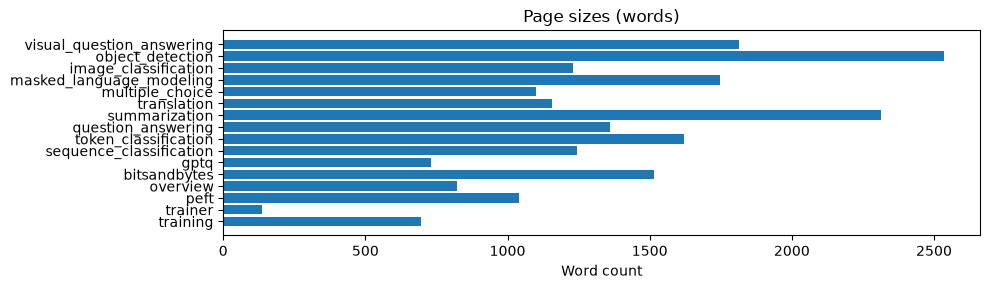

Total words: 21,063
Largest page: tasks/object_detection.md  (2,535 words)
Smallest page: trainer.md  (137 words)


In [16]:
word_counts = [len(p["content"].split()) for p in pages]

fig, ax = plt.subplots(figsize=(10, 3))
ax.barh([p["path"].split("/")[-1].replace(".md", "") for p in pages], word_counts)
ax.set_xlabel("Word count")
ax.set_title("Page sizes (words)")
plt.tight_layout()
plt.show()

largest = max(pages, key=lambda p: len(p["content"].split()))
smallest = min(pages, key=lambda p: len(p["content"].split()))
print(f"Total words: {sum(word_counts):,}")
print(f"Largest page: {largest['path']}  ({max(word_counts):,} words)")
print(f"Smallest page: {smallest['path']}  ({min(word_counts):,} words)")

In [17]:
# Spot-check: show the first 1000 chars of one page
sample = pages[0]
print(f"=== {sample['path']} ===")
print(sample["content"][:1000])

=== training.md ===
# Fine-tuning

Fine-tuning continues training a large pretrained model on a smaller dataset specific to a task or domain. For example, fine-tuning on a dataset of coding examples helps the model get better at coding. Fine-tuning is identical to pretraining except you don't start with random weights. It also requires far less compute, data, and time.

The tutorial below walks through fine-tuning a large language model with [`Trainer`].

Log in to your Hugging Face account with your user token to push your fine-tuned model to the Hub.

```py
from huggingface_hub import login

login()
```

## Tokenization

Load a dataset and [tokenize](./fast_tokenizers) the text column the model trains on (`horoscope` in the dataset below).

<iframe
  src="https://huggingface.co/datasets/karthiksagarn/astro_horoscope/embed/viewer/default/train"
  frameborder="0"
  width="100%"
  height="560px"
></iframe>

The tokenizer creates the model inputs, `input_ids` and `attention_mask`. The mo

## Chunks

In [18]:
with open(DATA / "chunks.json", encoding="utf-8") as f:
    chunks = json.load(f)

print(f"{len(chunks)} chunks from {len(pages)} pages")
print(f"Average chunks per page: {len(chunks) / len(pages):.1f}")

325 chunks from 16 pages
Average chunks per page: 20.3


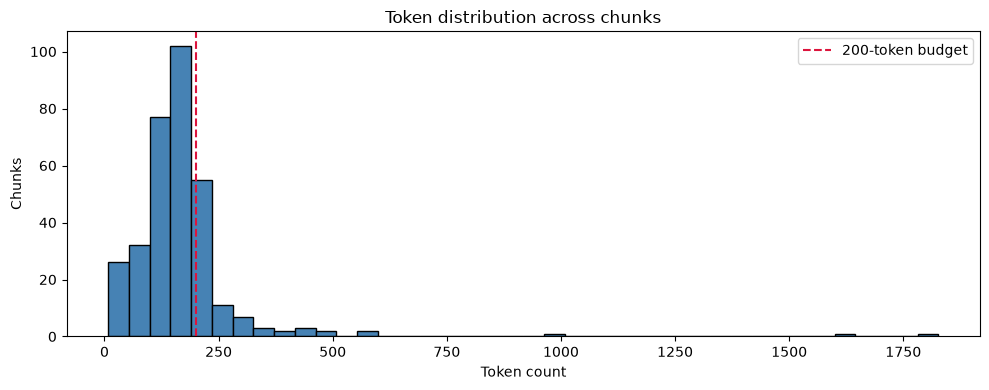

Min:    8
Median: 156
Mean:   171.3
Max:    1827
Over budget (atomic blocks): 56 / 325  (17.2%)


In [19]:
token_counts = [c["token_count"] for c in chunks]
over_budget = [c for c in chunks if c["token_count"] > 200]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_counts, bins=40, edgecolor="black", color="steelblue")
ax.axvline(
    200, color="crimson", linestyle="--", linewidth=1.5, label="200-token budget"
)
ax.set_xlabel("Token count")
ax.set_ylabel("Chunks")
ax.set_title("Token distribution across chunks")
ax.legend()
plt.tight_layout()
plt.show()

sorted_counts = sorted(token_counts)
n = len(sorted_counts)
print(f"Min:    {sorted_counts[0]}")
print(f"Median: {sorted_counts[n // 2]}")
print(f"Mean:   {sum(token_counts) / n:.1f}")
print(f"Max:    {sorted_counts[-1]}")
print(
    f"Over budget (atomic blocks): {len(over_budget)} / {n}  ({len(over_budget) / n * 100:.1f}%)"
)

In [20]:
# Chunks per page
chunks_per_page = Counter(c["page_path"] for c in chunks)

print(f"{'Page':<52} {'Chunks':>6}")
print("-" * 60)
for path, count in sorted(chunks_per_page.items(), key=lambda x: -x[1]):
    print(f"{path:<52} {count:>6}")

Page                                                 Chunks
------------------------------------------------------------
tasks/object_detection.md                                42
quantization/bitsandbytes.md                             36
tasks/visual_question_answering.md                       29
tasks/token_classification.md                            28
tasks/masked_language_modeling.md                        24
peft.md                                                  22
tasks/image_classification.md                            22
tasks/translation.md                                     19
tasks/question_answering.md                              18
tasks/summarization.md                                   18
tasks/multiple_choice.md                                 18
tasks/sequence_classification.md                         17
quantization/gptq.md                                     14
training.md                                              12
quantization/overview.md               

## Atomic blocks

Chunks exceeding the 200-token budget are code blocks or tables kept whole (Option A).

In [21]:
print(f"{len(over_budget)} atomic chunks (code blocks / tables):\n")
for c in over_budget:
    kind = "code" if "```" in c["content"] else "table"
    print(
        f"  {c['chunk_id']:<30} {c['token_count']:>4} tokens  [{kind}]  {c['page_path']}"
    )

56 atomic chunks (code blocks / tables):

  training_006                    205 tokens  [table]  training.md
  peft_002                        206 tokens  [code]  peft.md
  peft_010                        204 tokens  [code]  peft.md
  quantization_overview_000      1827 tokens  [table]  quantization/overview.md
  quantization_bitsandbytes_018   204 tokens  [code]  quantization/bitsandbytes.md
  quantization_gptq_002           201 tokens  [code]  quantization/gptq.md
  tasks_sequence_classification_003  380 tokens  [code]  tasks/sequence_classification.md
  tasks_sequence_classification_012  275 tokens  [code]  tasks/sequence_classification.md
  tasks_token_classification_003  218 tokens  [code]  tasks/token_classification.md
  tasks_token_classification_007  235 tokens  [code]  tasks/token_classification.md
  tasks_token_classification_008  202 tokens  [table]  tasks/token_classification.md
  tasks_token_classification_010  314 tokens  [code]  tasks/token_classification.md
  tasks_toke

In [22]:
# Show one atomic chunk in full
if over_budget:
    c = over_budget[0]
    print(f"=== {c['chunk_id']}  ({c['token_count']} tokens) ===")
    print(c["content"])

=== training_006  (205 tokens) ===
# Fine-tuning

## Training configuration  
[`TrainingArguments`] provides all the options for customizing a training run. Only the most common arguments are covered here. Everything else has reasonable defaults or is only relevant to specific scenarios like distributed training. See the [`TrainingArguments`] API docs for a complete list of arguments.  
<hfoptions id="training-args">
<hfoption id="training duration">  
- `num_train_epochs` and `per_device_train_batch_size` control training duration and batch size. `learning_rate` sets the initial learning rate for the optimizer.  
</hfoption>
<hfoption id="training optimizations">  
- Set `bf16=True` for fast mixed precision training if your hardware supports it (Ampere+ GPUs). Otherwise, fall back to `fp16=True` on older hardware.


## Sample chunks

In [23]:
# Three representative prose chunks
normal = [c for c in chunks if c["token_count"] <= 200]
step = len(normal) // 3

for c in normal[::step][:3]:
    print(
        f"=== {c['chunk_id']}  ({c['token_count']} tokens) | {c['heading'] or 'no heading'} ==="
    )
    print(c["content"])
    print()

=== training_000  (143 tokens) | no heading ===
# Fine-tuning

Fine-tuning continues training a large pretrained model on a smaller dataset specific to a task or domain. For example, fine-tuning on a dataset of coding examples helps the model get better at coding. Fine-tuning is identical to pretraining except you don't start with random weights. It also requires far less compute, data, and time.  
The tutorial below walks through fine-tuning a large language model with [`Trainer`].  
Log in to your Hugging Face account with your user token to push your fine-tuned model to the Hub.

```py
from huggingface_hub import login

login()
```

=== tasks_sequence_classification_006  (193 tokens) | Preprocess ===
# Text classification

To apply the preprocessing function over the entire dataset, use 🤗 Datasets [`~datasets.Dataset.map`] function. You can speed up `map` by setting `batched=True` to process multiple elements of the dataset at once:

```py
tokenized_imdb = imdb.map(preprocess_functi

## Validation

In [24]:
from transformers import AutoTokenizer

# 1. Title prefix appears exactly once in every chunk
title_problems = [
    c["chunk_id"] for c in chunks if c["content"].count(f"# {c['page_title']}") != 1
]
print(
    f"Title prefix duplicated: {len(title_problems)} chunks"
    if title_problems
    else "Title prefix: OK"
)

# 2. No empty content
empty = [c["chunk_id"] for c in chunks if not c["content"].strip()]
print(f"Empty chunks: {len(empty)}" if empty else "Empty chunks: none")

# 3. IDs are unique
ids = [c["chunk_id"] for c in chunks]
print(
    f"Duplicate IDs: {len(ids) - len(set(ids))}"
    if len(ids) != len(set(ids))
    else "Chunk IDs: unique"
)

# 4. Token counts match the stored value spot-check
tok = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
mismatches = [
    c["chunk_id"]
    for c in chunks[:50]  # spot-check first 50
    if len(tok.encode(c["content"])) != c["token_count"]
]
print(
    f"Token count mismatches (first 50): {len(mismatches)}"
    if mismatches
    else "Token counts: OK (spot-check)"
)

Title prefix: OK
Empty chunks: none
Chunk IDs: unique


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1827 > 512). Running this sequence through the model will result in indexing errors


Token counts: OK (spot-check)


## Corpus manifest

In [25]:
with open(DATA / "corpus_manifest.json") as f:
    manifest = json.load(f)

print(f"Repo:   {manifest['repo']}")
print(f"Commit: {manifest['commit_sha']}")
print(f"Files:  {manifest['count']}")

Repo:   huggingface/transformers
Commit: 5f98ac53ba599ee759b8ca1bb3eb0074bb9354ed
Files:  16
